# URBAN FLOOD STRESS | FEMA Flood Zones

Descarga la capa oficial `Flood Hazard Zones` del NFHL de FEMA.

Punto clave:
- OpenFEMA API no expone los polígonos de flood zones.
- El dato oficial para flood zones vive en el servicio GIS del NFHL.
- Las zonas vienen como polígonos, no por tract.


Fuente oficial:
- NFHL GIS Services de FEMA.
- Layer 28: `Flood Hazard Zones`.
- Si luego quieres resumen por tract, se puede hacer con un overlay adicional.


In [12]:
from __future__ import annotations

import json
import os
import time
from pathlib import Path

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.ops import unary_union
from shapely.validation import make_valid

plt.style.use('seaborn-v0_8-whitegrid')


In [13]:
session = requests.Session()
session.headers.update({'User-Agent': 'urban-flood-stress/1.0'})


def find_project_root() -> Path:
    """Locate the repository root from any notebook working directory."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    return current


def request_json(url, params=None, headers=None, retries=5, pause=1.5, method='GET'):
    """Fetch JSON with light retry/backoff handling."""
    params = params or {}
    headers = headers or {}
    last_error = None
    for attempt in range(retries):
        if method.upper() == 'POST':
            response = session.post(url, data=params, headers=headers, timeout=180)
        else:
            response = session.get(url, params=params, headers=headers, timeout=180)
        if response.status_code == 204:
            return {}
        if response.status_code in {429, 500, 502, 503, 504} and attempt < retries - 1:
            time.sleep(pause * (attempt + 1))
            continue
        try:
            response.raise_for_status()
        except Exception as exc:
            body = response.text.strip().replace('\n', ' ')[:500]
            raise RuntimeError(
                f'Request failed for {url}: {response.status_code} {response.reason}. {body}'
            ) from exc
        payload = response.json()
        if isinstance(payload, dict) and payload.get('error'):
            error = payload['error']
            if isinstance(error, dict):
                error = error.get('message') or error.get('details') or error
            raise RuntimeError(f'FEMA error for {url}: {error}')
        return payload
    if last_error is not None:
        raise RuntimeError(f'Request failed for {url}: {last_error}') from last_error
    raise RuntimeError(f'Unable to fetch {url}')


def chunked(values, size):
    """Yield fixed-size chunks from a list-like sequence."""
    for start in range(0, len(values), size):
        yield values[start:start + size]


ROOT = find_project_root()
SPATIAL_OUT = ROOT / 'data' / 'spatial' / 'vector' / 'fema_nfhl'
TEMPORAL_OUT = ROOT / 'data' / 'temporal' / 'fema_nfhl'
SPATIAL_OUT.mkdir(parents=True, exist_ok=True)
TEMPORAL_OUT.mkdir(parents=True, exist_ok=True)

NYC_BOUNDARY = ROOT / 'data' / 'spatial' / 'vector' / 'nyc_borough_boundary' / 'nybb.geojson'
NFHL_BASE = 'https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer'
FLOOD_ZONES_LAYER = 28
NFHL_QUERY = f'{NFHL_BASE}/{FLOOD_ZONES_LAYER}/query'


def load_nyc_boundary():
    """Load the NYC borough boundary and merge it into one valid geometry."""
    nyc = gpd.read_file(NYC_BOUNDARY)
    nyc = nyc.copy()
    nyc['geometry'] = nyc.geometry.apply(make_valid)
    city = unary_union(nyc.geometry)
    return nyc, city


def arcgis_query(params, method='GET'):
    """Call the FEMA NFHL ArcGIS query endpoint."""
    return request_json(NFHL_QUERY, params=params, method=method)


def fetch_zone_object_ids(bounds):
    """Get the object IDs that intersect one bounding box."""
    xmin, ymin, xmax, ymax = bounds
    payload = arcgis_query(
        {
            'where': '1=1',
            'geometry': f'{xmin},{ymin},{xmax},{ymax}',
            'geometryType': 'esriGeometryEnvelope',
            'inSR': 4326,
            'spatialRel': 'esriSpatialRelIntersects',
            'returnIdsOnly': 'true',
            'f': 'json',
        }
    )
    object_ids = payload.get('objectIds') or []
    return sorted(int(value) for value in object_ids)


def fetch_zone_batch(object_ids):
    """Fetch one batch of flood zone polygons by object ID."""
    payload = arcgis_query(
        {
            'objectIds': ','.join(map(str, object_ids)),
            'outFields': 'OBJECTID,FLD_ZONE,ZONE_SUBTY',
            'returnGeometry': 'true',
            'outSR': 4326,
            'f': 'geojson',
        },
        method='POST',
    )
    features = payload.get('features', [])
    if not features:
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')
    return gpd.GeoDataFrame.from_features(features, crs='EPSG:4326')


def fetch_zone_batch_safe(object_ids, depth=0, max_depth=6):
    """Fetch a batch and split it if FEMA rejects the request."""
    if not object_ids:
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

    try:
        return fetch_zone_batch(object_ids)
    except Exception as exc:
        if len(object_ids) == 1 or depth >= max_depth:
            raise RuntimeError(f'FEMA batch failed for {len(object_ids)} IDs') from exc
        mid = max(1, len(object_ids) // 2)
        left = fetch_zone_batch_safe(object_ids[:mid], depth=depth + 1, max_depth=max_depth)
        right = fetch_zone_batch_safe(object_ids[mid:], depth=depth + 1, max_depth=max_depth)
        if left.empty and right.empty:
            return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')
        return pd.concat([left, right], ignore_index=True)


def download_nfhl_flood_zones(bounds, batch_size=25):
    """Download NFHL flood hazard zones for one bounding box."""
    object_ids = fetch_zone_object_ids(bounds)
    if not object_ids:
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

    frames = []
    for batch in chunked(object_ids, batch_size):
        frame = fetch_zone_batch_safe(batch)
        if not frame.empty:
            frames.append(frame)
        time.sleep(0.05)

    if not frames:
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

    combined = pd.concat(frames, ignore_index=True)
    dedupe_key = next((c for c in ('OBJECTID', 'objectid', 'OBJECTID_1') if c in combined.columns), None)
    if dedupe_key is not None:
        combined = combined.drop_duplicates(subset=[dedupe_key])
    combined = combined.reset_index(drop=True)
    return gpd.GeoDataFrame(combined, geometry='geometry', crs='EPSG:4326')


def clip_to_boundary(frame, boundary_geom):
    """Clip polygon features to the NYC boundary."""
    if frame.empty:
        return frame.copy()
    clipped = frame.copy()
    clipped['geometry'] = clipped.geometry.intersection(boundary_geom)
    clipped = clipped[~clipped.geometry.is_empty].copy()
    clipped = clipped[clipped.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
    clipped['geometry'] = clipped.geometry.apply(make_valid)
    return clipped.reset_index(drop=True)


def summarize_area(frame):
    """Summarize clipped flood zones by zone code and subtype."""
    columns = ['FLD_ZONE', 'ZONE_SUBTY', 'features', 'area_sq_km']
    if frame.empty:
        return pd.DataFrame(columns=columns)
    projected = frame.to_crs(2263).copy()
    projected['area_sq_km'] = projected.geometry.area * 0.09290304 / 1_000_000
    summary = (
        projected.groupby(['FLD_ZONE', 'ZONE_SUBTY'], dropna=False)
        .agg(features=('geometry', 'size'), area_sq_km=('area_sq_km', 'sum'))
        .reset_index()
        .sort_values('area_sq_km', ascending=False)
        .reset_index(drop=True)
    )
    return summary


def set_map_extent(ax, geom, pad=0.03):
    """Set map limits around one geometry."""
    minx, miny, maxx, maxy = geom.bounds
    dx = (maxx - minx) * pad
    dy = (maxy - miny) * pad
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)


def save_geojson(frame, path):
    """Write a GeoDataFrame as GeoJSON, even when it is empty."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if frame.empty:
        path.write_text(json.dumps({'type': 'FeatureCollection', 'features': []}))
        return
    frame.to_file(path, driver='GeoJSON')


In [14]:
nyc_boroughs, nyc_union = load_nyc_boundary()
flood_zones_raw = download_nfhl_flood_zones(nyc_union.bounds)
flood_zones_clipped = clip_to_boundary(flood_zones_raw, nyc_union)
flood_zone_summary = summarize_area(flood_zones_clipped)

print(f'raw features: {len(flood_zones_raw)}')
print(f'clipped features: {len(flood_zones_clipped)}')
flood_zone_summary.head(10)


raw features: 7715
clipped features: 2199


,FLD_ZONE,ZONE_SUBTY,features,area_sq_km
0,X,AREA OF MINIMAL FLOOD HAZARD,512,649.079267
1,AE,NaN,488,72.684008
2,X,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,1052,42.769635
3,VE,NaN,91,7.807969
4,OPEN WATER,NaN,4,4.791674
5,A,NaN,17,4.751027
6,AE,FLOODWAY,35,0.918649


In [15]:
raw_out = SPATIAL_OUT / 'nyc_nfhl_flood_zones_raw.geojson'
clipped_out = SPATIAL_OUT / 'nyc_nfhl_flood_zones.geojson'
summary_out = TEMPORAL_OUT / 'nyc_nfhl_flood_zone_summary.csv'

save_geojson(flood_zones_raw, raw_out)
save_geojson(flood_zones_clipped, clipped_out)
flood_zone_summary.to_csv(summary_out, index=False)

print(raw_out)
print(clipped_out)
print(summary_out)


/home/map10194/Documents/urban-flood-stress/data/spatial/vector/fema_nfhl/nyc_nfhl_flood_zones_raw.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/fema_nfhl/nyc_nfhl_flood_zones.geojson
/home/map10194/Documents/urban-flood-stress/data/temporal/fema_nfhl/nyc_nfhl_flood_zone_summary.csv


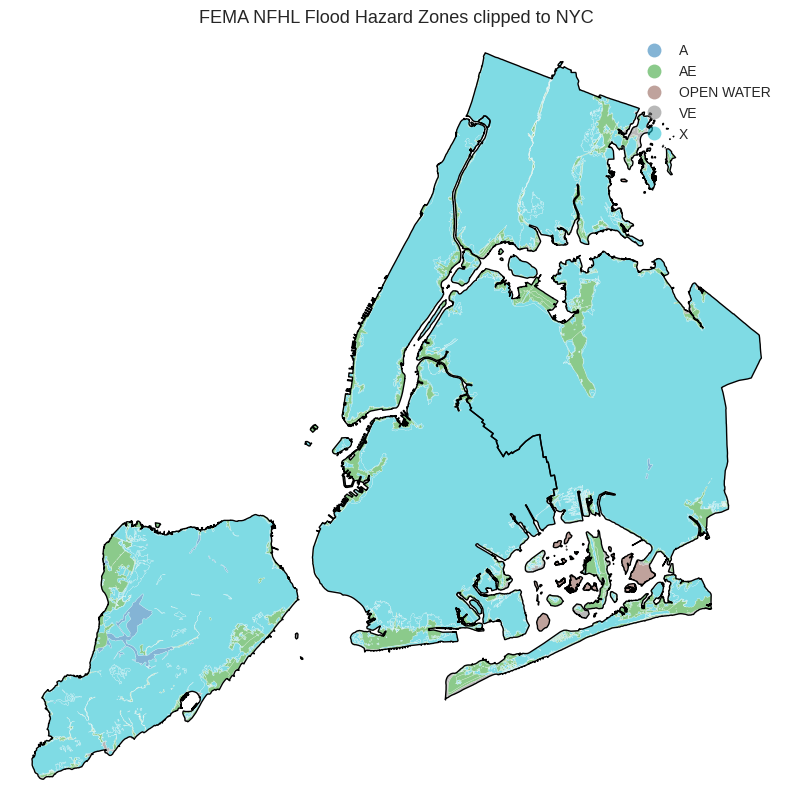

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
nyc_boroughs.boundary.plot(ax=ax, color='black', linewidth=1)
if not flood_zones_clipped.empty:
    flood_zones_clipped.plot(
        ax=ax,
        column='FLD_ZONE',
        categorical=True,
        legend=True,
        alpha=0.55,
        edgecolor='white',
        linewidth=0.25,
    )
set_map_extent(ax, nyc_union, pad=0.03)
ax.set_title('FEMA NFHL Flood Hazard Zones clipped to NYC', fontsize=13)
ax.set_axis_off()
plt.show()


In [17]:
flood_zone_summary

,FLD_ZONE,ZONE_SUBTY,features,area_sq_km
0,X,AREA OF MINIMAL FLOOD HAZARD,512,649.079267
1,AE,NaN,488,72.684008
2,X,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,1052,42.769635
3,VE,NaN,91,7.807969
4,OPEN WATER,NaN,4,4.791674
5,A,NaN,17,4.751027
6,AE,FLOODWAY,35,0.918649


Nota breve:
- Estas geometrías no vienen por tract.
- Si quieres una tabla por census tract, el siguiente paso es cruzar este GeoJSON con los tracts de NYC.
